In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

ratings_df = pd.read_csv('data/ratings.csv')
ratings_df

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119
...,...,...,...,...
33832157,330975,8340,2.0,1091583256
33832158,330975,8493,2.5,1091585709
33832159,330975,8622,4.0,1091581777
33832160,330975,8665,3.0,1091581765


In [12]:
ratings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 1.0 GB


In [13]:
ratings_df.describe()

,userId,movieId,rating,timestamp
count,3.383216e+07,3.383216e+07,3.383216e+07,3.383216e+07
mean,1.654380e+05,2.831348e+04,3.542540e+00,1.269362e+09
std,9.534122e+04,4.992865e+04,1.063959e+00,2.541023e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,8.295300e+04,1.219000e+03,3.000000e+00,1.046718e+09
50%,1.661290e+05,3.263000e+03,4.000000e+00,1.264740e+09
75%,2.474500e+05,4.049100e+04,4.000000e+00,1.496919e+09
max,3.309750e+05,2.889830e+05,5.000000e+00,1.689843e+09


<Axes: >

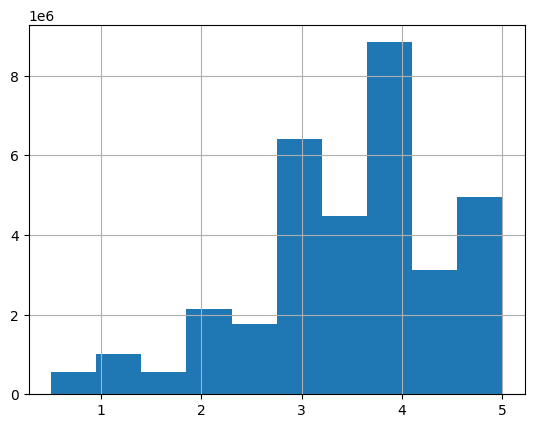

In [14]:
ratings_df['rating'].hist()

In [55]:
ratings_df.shape[0] / ratings_df["movieId"].unique().shape[0]  


406.4460409183195

On avarage, there are 406 ratings per movie

<Axes: >

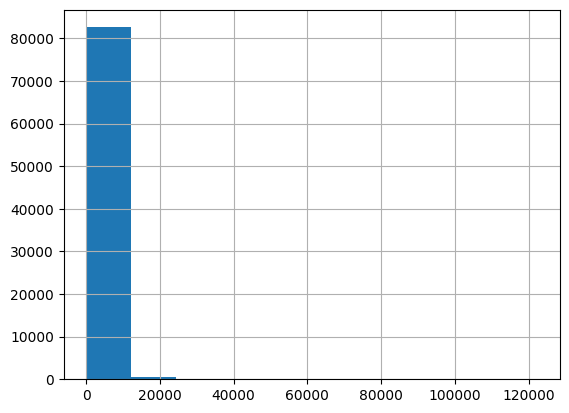

In [56]:
ratings_per_movie = ratings_df.groupby('movieId')['rating'].count()
ratings_per_movie.hist()

A few films gets a lot of ratings, while other hardly gets any ratings at all

userId
244882        1
314983        1
199467        1
103177        1
218132        1
          ...  
76618      8919
175998     9016
207216     9178
48766      9554
189614    33332
Name: rating, Length: 330975, dtype: int64

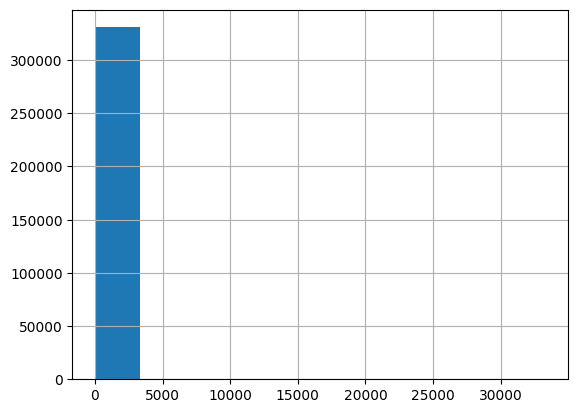

In [17]:
ratings_per_user = ratings_df.groupby('userId')['rating'].count().sort_values()
ratings_per_user.hist()
ratings_per_user

Some users rate a lot of movies, and some users rates few movies

movieId
213998    0.5
157089    0.5
276639    0.5
276637    0.5
276605    0.5
         ... 
181765    5.0
241926    5.0
241936    5.0
227628    5.0
178417    5.0
Name: rating, Length: 83239, dtype: float64

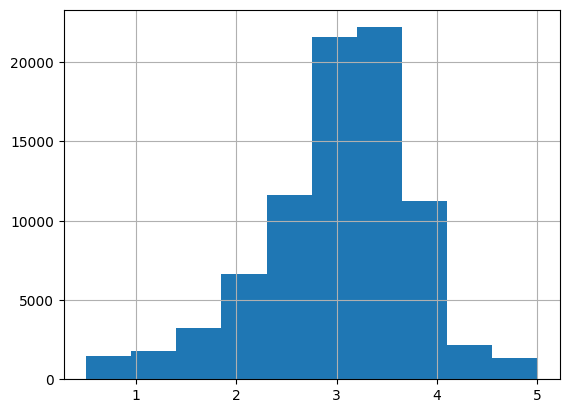

In [18]:
movie_scores = ratings_df.groupby('movieId')['rating'].mean().sort_values()
movie_scores.hist()
movie_scores

Most movies get a score around 3.0-3.5. Movies scooring lower than 2 could be filtered

In [71]:
lowest_acceptable_mean_rating_score = 3.0 
lowest_acceptable_rating_count = 100

good_movie_scores = movie_scores[movie_scores >= lowest_acceptable_mean_rating_score].index
ratings_filtered_df = ratings_df[ratings_df["movieId"].isin(good_movie_scores)]

popular_movie = ratings_per_movie[ratings_per_movie >= lowest_acceptable_rating_count].index
ratings_filtered_df = ratings_filtered_df[ratings_filtered_df["movieId"].isin(popular_movie)]


print(f"Number of rows after filtering is {(100*ratings_filtered_df.shape[0] / ratings_df.shape[0]):.1f} % of the size of original dataframe")
print(f"Number of films after filtering is {(100*ratings_filtered_df["movieId"].nunique() / ratings_df["movieId"].nunique()):.1f} % of the size of original dataframe")
print(f"Number of users after filtering is {(100*ratings_filtered_df["userId"].nunique() / ratings_df["userId"].nunique()):.1f} % of the size of original dataframe")



Number of rows after filtering is 86.3 % of the size of original dataframe
Number of films after filtering is 11.2 % of the size of original dataframe
Number of users after filtering is 99.7 % of the size of original dataframe
